In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import FunctionTransformer

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

from sklearn.decomposition import PCA

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.inspection import PartialDependenceDisplay

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 7043
Columns: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [5]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [6]:
X = df.drop(["Churn","customerID"], axis=1)
y = df["Churn"]

In [7]:
numerical_features = X.select_dtypes(include=["int64","float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns

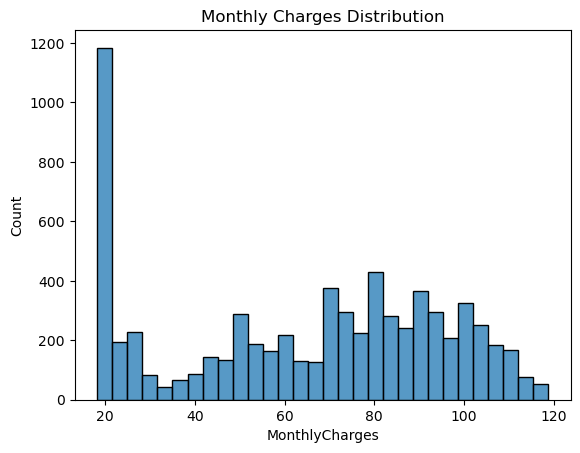

In [8]:
sns.histplot(df["MonthlyCharges"], bins=30)
plt.title("Monthly Charges Distribution")
plt.show()

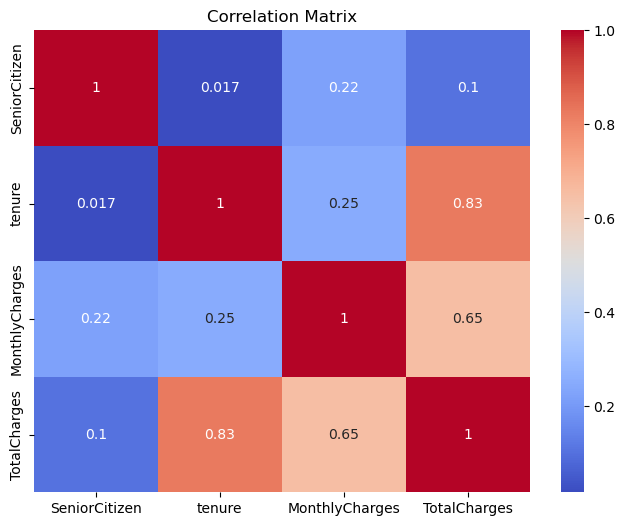

In [9]:
plt.figure(figsize=(8,6))

sns.heatmap(df[numerical_features].corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

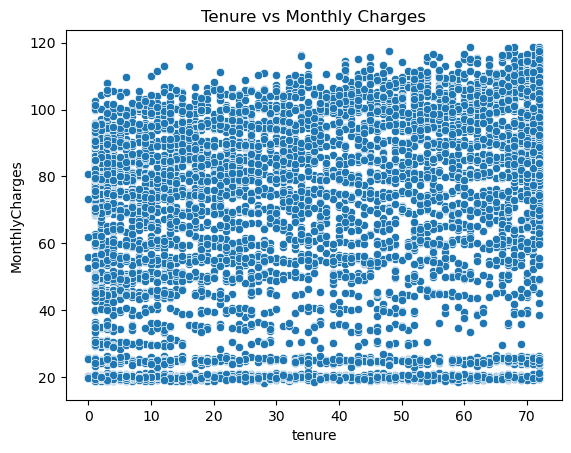

In [10]:
sns.scatterplot(x="tenure",
                y="MonthlyCharges",
                data=df)

plt.title("Tenure vs Monthly Charges")
plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [13]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [14]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_features),
    ("cat", cat_pipeline, categorical_features)
])

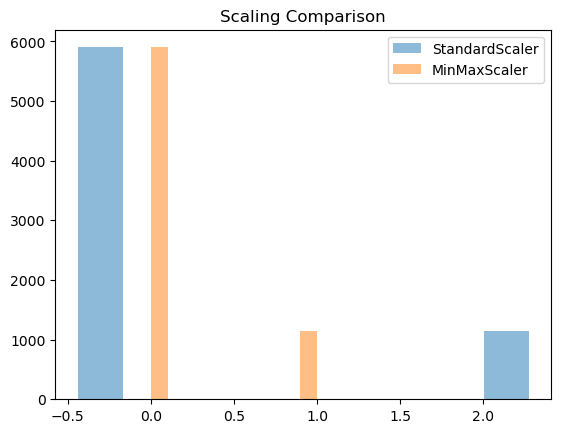

In [15]:
minmax = MinMaxScaler()

scaled_std = StandardScaler().fit_transform(df[numerical_features])
scaled_mm = minmax.fit_transform(df[numerical_features])

plt.hist(scaled_std[:,0], alpha=0.5, label="StandardScaler")
plt.hist(scaled_mm[:,0], alpha=0.5, label="MinMaxScaler")

plt.legend()
plt.title("Scaling Comparison")
plt.show()

In [16]:
log_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

log_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [17]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier())
])

rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
log_pred = log_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

print("Logistic Accuracy:",
      accuracy_score(y_test, log_pred))

print("RandomForest Accuracy:",
      accuracy_score(y_test, rf_pred))

Logistic Accuracy: 0.8211497515968772
RandomForest Accuracy: 0.7892122072391767


In [19]:
poly_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("poly", PolynomialFeatures(degree=2)),
    ("model", LogisticRegression(max_iter=1000))
])

In [20]:
pca_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("pca", PCA(n_components=10)),
    ("model", LogisticRegression(max_iter=1000))
])

pca_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
pred = rf_pipeline.predict(X_test)

print(confusion_matrix(y_test, pred))

print(classification_report(y_test, pred))

[[938  98]
 [199 174]]
              precision    recall  f1-score   support

          No       0.82      0.91      0.86      1036
         Yes       0.64      0.47      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [22]:
scores = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=5
)

print("CV Scores:", scores)
print("Average:", scores.mean())

CV Scores: [0.79418027 0.78353442 0.76863023 0.79332386 0.79900568]
Average: 0.7877348941867217


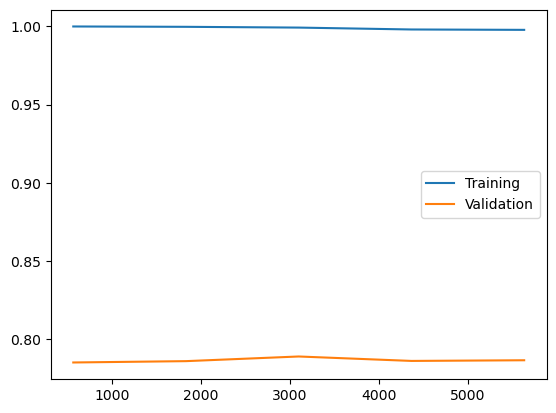

In [23]:
train_sizes, train_scores, test_scores = learning_curve(
    rf_pipeline,
    X,
    y,
    cv=5
)

plt.plot(train_sizes,
         train_scores.mean(axis=1),
         label="Training")

plt.plot(train_sizes,
         test_scores.mean(axis=1),
         label="Validation")

plt.legend()
plt.show()

In [24]:
param_range = [50,100,200]

train_scores, test_scores = validation_curve(
    RandomForestClassifier(),
    X_train[numerical_features],
    y_train,
    param_name="n_estimators",
    param_range=param_range,
    cv=3
)

In [25]:
param_grid = {
    "model__n_estimators":[100,200],
    "model__max_depth":[5,10]
}

grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'model__max_depth': 10, 'model__n_estimators': 200}


In [26]:
param_dist = {
    "model__n_estimators":[50,100,200,300],
    "model__max_depth":[5,10,15]
}

random = RandomizedSearchCV(
    rf_pipeline,
    param_dist,
    cv=3
)

random.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'model__max_depth': [5, 10, ...], 'model__n_estimators': [50, 100, ...]}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [27]:
class TenureTransformer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["tenure_years"] = X["tenure"]/12
        return X

In [28]:
log_transformer = FunctionTransformer(np.log1p)

In [29]:
feature_union = FeatureUnion([
    ("pca", PCA(n_components=5)),
    ("select", SelectKBest(chi2, k=5))
])

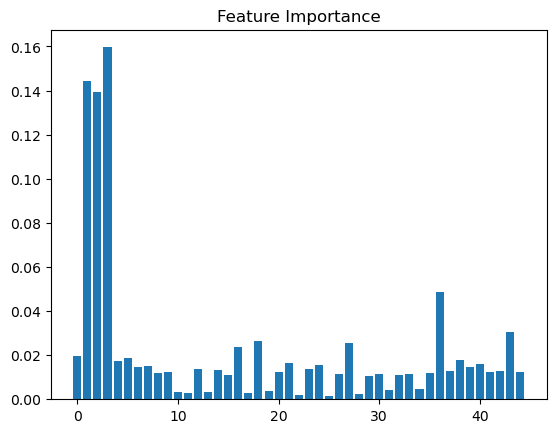

In [30]:
rf = RandomForestClassifier()

rf.fit(pd.get_dummies(X_train), y_train)

importance = rf.feature_importances_

plt.bar(range(len(importance)), importance)

plt.title("Feature Importance")

plt.show()

C:\Users\gsrav\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 4 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


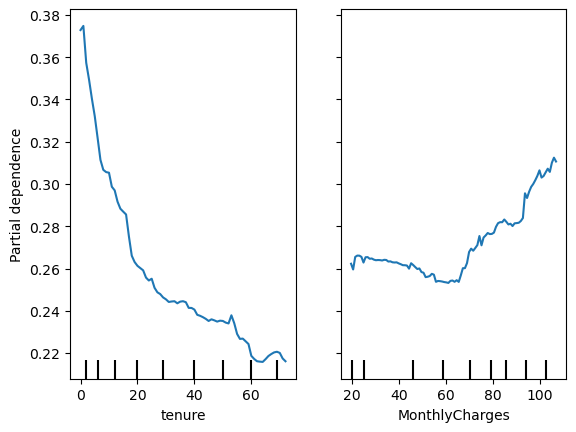

In [31]:
PartialDependenceDisplay.from_estimator(
    rf_pipeline,
    X_train,
    ["tenure","MonthlyCharges"]
)

plt.show()

In [32]:
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200
    ))
])

final_pipeline.fit(X_train, y_train)

final_pred = final_pipeline.predict(X_test)

print("Final Accuracy:",
      accuracy_score(y_test, final_pred))

Final Accuracy: 0.7877927608232789
